# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pandas_datareader import data as pdr

import datetime

In [7]:
import requests

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"

r = requests.get(url)

print(r.status_code)
print(r.text[:100])

200
observation_date,UNRATE
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5
1


In [8]:
import pandas as pd

def get_fred_data(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("observation_date")
    return df


unemployment = get_fred_data("UNRATE")
cpi = get_fred_data("CPIAUCSL")
interest = get_fred_data("FEDFUNDS")
m2 = get_fred_data("M2SL")
gdp = get_fred_data("GDP")

In [11]:
print(unemployment.head())
print(cpi.head())
print(interest.head())
print(m2.head())
print(gdp.head())

                  UNRATE
observation_date        
1948-01-01           3.4
1948-02-01           3.8
1948-03-01           4.0
1948-04-01           3.9
1948-05-01           3.5
                  CPIAUCSL
observation_date          
1947-01-01           21.48
1947-02-01           21.62
1947-03-01           22.00
1947-04-01           22.00
1947-05-01           21.95
                  FEDFUNDS
observation_date          
1954-07-01            0.80
1954-08-01            1.22
1954-09-01            1.07
1954-10-01            0.85
1954-11-01            0.83
                   M2SL
observation_date       
1959-01-01        286.6
1959-02-01        287.7
1959-03-01        289.2
1959-04-01        290.1
1959-05-01        292.2
                      GDP
observation_date         
1947-01-01        243.164
1947-04-01        245.968
1947-07-01        249.585
1947-10-01        259.745
1948-01-01        265.742


In [12]:
print("Unemployment:", unemployment.shape)
print("CPI:", cpi.shape)
print("Interest:", interest.shape)
print("M2:", m2.shape)
print("GDP:", gdp.shape)

Unemployment: (942, 1)
CPI: (954, 1)
Interest: (865, 1)
M2: (810, 1)
GDP: (318, 1)


In [13]:
unemployment.columns = ["Unemployment"]
cpi.columns = ["CPI"]
interest.columns = ["Interest"]
m2.columns = ["M2"]
gdp.columns = ["GDP"]

In [15]:
unemployment_q = unemployment.resample("QE").mean()
cpi_q = cpi.resample("QE").mean()
interest_q = interest.resample("QE").mean()
m2_q = m2.resample("QE").mean()

In [16]:
gdp_q = gdp

In [17]:
df = unemployment_q.join(
    [cpi_q, interest_q, m2_q, gdp_q],
    how="inner"
)

In [18]:
print(df.head())

Empty DataFrame
Columns: [Unemployment, CPI, Interest, M2, GDP]
Index: []


In [19]:
print(df.shape)

(0, 5)


In [21]:
print(gdp.head())

                      GDP
observation_date         
1947-01-01        243.164
1947-04-01        245.968
1947-07-01        249.585
1947-10-01        259.745
1948-01-01        265.742


In [22]:
unemployment_q.index = unemployment_q.index.to_period("Q")
cpi_q.index = cpi_q.index.to_period("Q")
interest_q.index = interest_q.index.to_period("Q")
m2_q.index = m2_q.index.to_period("Q")
gdp_q.index = gdp_q.index.to_period("Q")

In [23]:
df = unemployment_q.join(
    [cpi_q, interest_q, m2_q, gdp_q],
    how="inner"
)

In [24]:
print(df.head())

                  Unemployment        CPI  Interest          M2      GDP
observation_date                                                        
1959Q1                5.833333  28.993333  2.570000  287.833333  510.330
1959Q2                5.100000  29.043333  3.083333  292.133333  522.653
1959Q3                5.266667  29.193333  3.576667  296.100000  525.034
1959Q4                5.600000  29.370000  3.990000  297.133333  528.600
1960Q1                5.133333  29.396667  3.933333  298.633333  542.648


In [25]:
print(df.shape)

(270, 5)


In [26]:
df.isnull().sum()

Unemployment    0
CPI             0
Interest        0
M2              0
GDP             0
dtype: int64

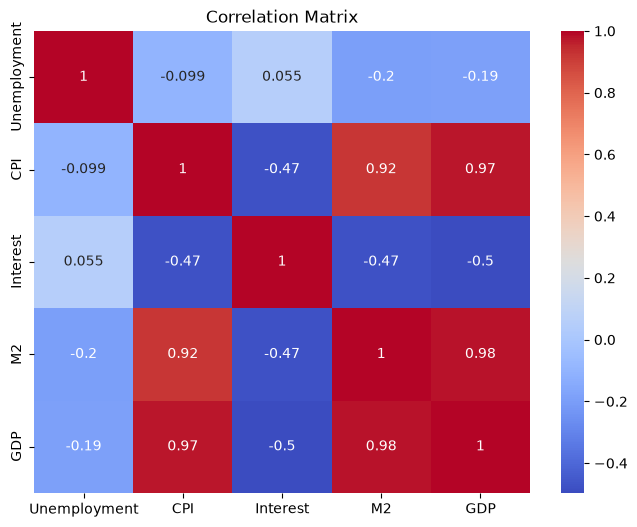

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [29]:
corr = df.corr()

print(corr)

              Unemployment       CPI  Interest        M2       GDP
Unemployment      1.000000 -0.099488  0.054966 -0.196982 -0.192255
CPI              -0.099488  1.000000 -0.474743  0.923562  0.974249
Interest          0.054966 -0.474743  1.000000 -0.474284 -0.496668
M2               -0.196982  0.923562 -0.474284  1.000000  0.979592
GDP              -0.192255  0.974249 -0.496668  0.979592  1.000000


In [30]:
df_growth = df.pct_change()*100

In [31]:
X = df.drop("Unemployment", axis=1)

y = df["Unemployment"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.07,-0.07, 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['CPI','Interest','M2','GDP']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.046
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.0512956928386
MSE: 1.8651746580591766
RMSE: 1.365713973736513
R² Score: -0.026445878042349547


In [38]:
df_model = df.copy()

df_model["GDP_Growth"] = df_model["GDP"].pct_change()*100
df_model["CPI_Growth"] = df_model["CPI"].pct_change()*100
df_model["M2_Growth"] = df_model["M2"].pct_change()*100

print(df_model.head())

                  Unemployment        CPI  Interest          M2      GDP  \
observation_date                                                           
1959Q1                5.833333  28.993333  2.570000  287.833333  510.330   
1959Q2                5.100000  29.043333  3.083333  292.133333  522.653   
1959Q3                5.266667  29.193333  3.576667  296.100000  525.034   
1959Q4                5.600000  29.370000  3.990000  297.133333  528.600   
1960Q1                5.133333  29.396667  3.933333  298.633333  542.648   

                  GDP_Growth  CPI_Growth  M2_Growth  
observation_date                                     
1959Q1                   NaN         NaN        NaN  
1959Q2              2.414712    0.172453   1.493920  
1959Q3              0.455560    0.516470   1.357827  
1959Q4              0.679194    0.605161   0.348981  
1960Q1              2.657586    0.090796   0.504824  


In [39]:
df_model = df_model.dropna()

print(df_model.shape)

(269, 8)


In [40]:
df_model = df_model.dropna()

df_model.shape

(269, 8)

In [41]:
df_model.corr()["Unemployment"].sort_values()

M2             -0.197295
GDP            -0.192672
CPI            -0.099842
GDP_Growth     -0.089007
CPI_Growth     -0.008394
Interest        0.054988
M2_Growth       0.377761
Unemployment    1.000000
Name: Unemployment, dtype: float64

In [42]:
# Remove missing values
df_model = df_model.dropna()


# Define features and target
X = df_model[
    [
        "GDP_Growth",
        "CPI_Growth",
        "M2_Growth",
        "Interest"
    ]
]

y = df_model["Unemployment"]


# Time-based train/test split
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


# Build Linear Regression model
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

model2.fit(X_train, y_train)


# Prediction
y_pred2 = model2.predict(X_test)


# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
r2 = r2_score(y_test, y_pred2)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.5136815092655114
RMSE: 1.6526353873034896
R² Score: 0.02065117482999468


In [43]:
df_lag = df_model.copy()

df_lag["Unemployment_Lag1"] = df_lag["Unemployment"].shift(1)

df_lag.head()

,Unemployment,CPI,Interest,M2,GDP,GDP_Growth,CPI_Growth,M2_Growth,Unemployment_Lag1
observation_date,,,,,,,,,
1959Q2,5.100000,29.043333,3.083333,292.133333,522.653,2.414712,0.172453,1.493920,NaN
1959Q3,5.266667,29.193333,3.576667,296.100000,525.034,0.455560,0.516470,1.357827,5.100000
1959Q4,5.600000,29.370000,3.990000,297.133333,528.600,0.679194,0.605161,0.348981,5.266667
1960Q1,5.133333,29.396667,3.933333,298.633333,542.648,2.657586,0.090796,0.504824,5.600000
1960Q2,5.233333,29.573333,3.696667,301.100000,541.080,-0.288953,0.600975,0.825985,5.133333


In [44]:
df_lag = df_lag.dropna()

In [45]:
print(df_lag.head())

                  Unemployment        CPI  Interest          M2      GDP  \
observation_date                                                           
1959Q3                5.266667  29.193333  3.576667  296.100000  525.034   
1959Q4                5.600000  29.370000  3.990000  297.133333  528.600   
1960Q1                5.133333  29.396667  3.933333  298.633333  542.648   
1960Q2                5.233333  29.573333  3.696667  301.100000  541.080   
1960Q3                5.533333  29.590000  2.936667  306.466667  545.604   

                  GDP_Growth  CPI_Growth  M2_Growth  Unemployment_Lag1  
observation_date                                                        
1959Q3              0.455560    0.516470   1.357827           5.100000  
1959Q4              0.679194    0.605161   0.348981           5.266667  
1960Q1              2.657586    0.090796   0.504824           5.600000  
1960Q2             -0.288953    0.600975   0.825985           5.133333  
1960Q3              0.836106 

In [46]:
# Remove missing values
df_lag = df_lag.dropna()


# Features and target
X = df_lag[
    [
        "GDP_Growth",
        "CPI_Growth",
        "M2_Growth",
        "Interest",
        "Unemployment_Lag1"
    ]
]

y = df_lag["Unemployment"]


# Time-based split
split = int(len(df_lag) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


# Linear Regression
from sklearn.linear_model import LinearRegression

model3 = LinearRegression()

model3.fit(X_train, y_train)


# Prediction
y_pred3 = model3.predict(X_test)


# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred3)
rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
r2 = r2_score(y_test, y_pred3)


print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.39108630922684345
RMSE: 0.9940208210746619
R² Score: 0.6456974536656279


In [47]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model3.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,Unemployment_Lag1,0.983315
1,CPI_Growth,0.147737
2,M2_Growth,0.067598
3,Interest,0.007410
0,GDP_Growth,-0.239672


In [48]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred3
})

results.head()

,Actual,Predicted
observation_date,,
2013Q1,7.733333,7.702168
2013Q2,7.533333,7.754247
2013Q3,7.233333,7.465841
2013Q4,6.933333,7.169256
2014Q1,6.666667,7.208621


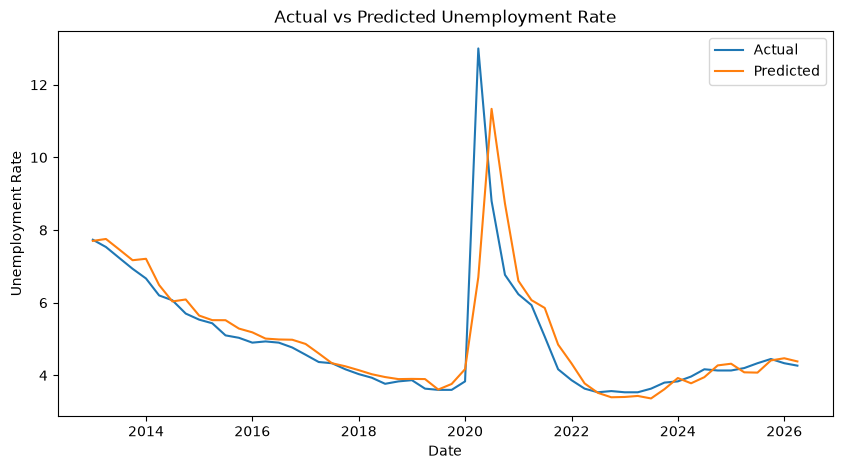

In [51]:
results_plot = results.copy()

results_plot.index = results_plot.index.to_timestamp()

plt.figure(figsize=(10,5))

plt.plot(results_plot.index, results_plot["Actual"], label="Actual")
plt.plot(results_plot.index, results_plot["Predicted"], label="Predicted")

plt.title("Actual vs Predicted Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")

plt.legend()
plt.show()

In [69]:
import plotly.express as px

results_plot = results.copy()

results_plot.index = results_plot.index.to_timestamp()

results_plot = results_plot.reset_index()

fig = px.line(
    results_plot,
    x="observation_date",
    y=["Actual", "Predicted"],
    title="Actual vs Predicted Unemployment Rate"
)
fig.show(renderer="browser")

In [67]:
fig.write_html("actual_vs_predicted.html")